#  1. Eigenschaft vs. Rente pro Institution



# A) Vorbereitung

Notwendige Packages

In [4]:
import os
import glob
import pandas as pd
from lxml import etree as ET
from collections import Counter
from rapidfuzz import fuzz
from IPython.display import display, HTML
from pyproj import Transformer
import matplotlib.pyplot as plt


# Datenset einlesen

Dafür muss sich das Datset im selben lokalen Ordner befinden, wie das Notebook.

In [5]:
rentsall_korrektur_df = pd.read_csv('rentsall_korrektur_df.csv')

In [6]:
# 1. Alle einzigartigen Kategorien alphabetisch sortiert anzeigen
unique_causes = sorted(rentsall_korrektur_df['cause'].unique().astype(str))
print("Vorhandene Kategorien in 'cause':")
print(unique_causes)

# 2. Bonus: Direkt anzeigen, wie oft jede Kategorie vorkommt (Häufigkeit)
print("\nAnzahl der Einträge pro Kategorie:")
print(rentsall_korrektur_df['cause'].value_counts())

Vorhandene Kategorien in 'cause':
[np.str_('2.0 UNKNOWN'), np.str_('Alle 4 Fronfasten'), np.str_('Bodenzins'), np.str_('Ehrschatz'), np.str_('Eigenschaft'), np.str_('Fasnachtshühner'), np.str_('Hauptgut'), np.str_('Jahrzeitenzins'), np.str_('Rente'), np.str_('Rentenkauf'), np.str_('Selgerete'), np.str_('UNKNOWN'), np.str_('UNKNOWN: Angabe/Abgabe'), np.str_('UNKNOWN: Angaria'), np.str_('UNKNOWN: Erbschaft'), np.str_('UNKNOWN: Farzit'), np.str_('UNKNOWN: Fastnacht'), np.str_('UNKNOWN: Honorar'), np.str_('UNKNOWN: Lehen'), np.str_('UNKNOWN: Martini'), np.str_('UNKNOWN: Morgengabe'), np.str_('UNKNOWN: Sache'), np.str_('UNKNOWN: Selbuch'), np.str_('UNKNOWN: Time/Feast (Fasnacht)'), np.str_('UNKNOWN: Wasserrecht'), np.str_('UNKNOWN: Zins'), np.str_('UNKNOWN: Zunft'), np.str_('UNKNOWN: inheritance'), np.str_('UNKNOWN: interest'), np.str_('UNKNOWN: lifetime'), np.str_('UNKNOWN: payment'), np.str_('Weingelt'), np.str_('Weisung'), np.str_('nan'), np.str_('not_mentioned'), np.str_('unk unk'), np.

In [7]:
# Zeigt die Datentypen aller Spalten
print(rentsall_korrektur_df.dtypes)

collection_id              object
collection_street          object
collection_house           object
collection_coord_x        float64
collection_coord_y        float64
id                          int64
dossier                    object
pages                      object
year                      float64
text                       object
language                   object
imagelinks                 object
source                     object
db_id                      object
file                       object
property_purchase_case     object
dues_case                  object
beneficiary                object
claimantOrg                object
interest                   object
interest_norm              object
interest_pd               float64
cause                      object
redeemable                 object
redeemable_amount          object
redeemable_amount_norm     object
redeemable_amount_pd       object
dues_text                  object
renteabloesig              object
hauptgutabloes

## Zusammensetzung bestimmter Causes

- Renten

Das Festhalten des exakten Zeitpunktes eines Kaufes einer Rente ist für meine Analyse nicht wichtig, weil wir das exakte Ende einer Rente selten bestimmen können.
Der Vergleich zwischen Renten und anderen Zinsarten ist wichtiger. Deswegen vereinheitliche ich die die Treffer Renten und Rentenkauf

In [8]:
# Alle exakten Treffer von "Rentenkauf" in "Rente" umbenennen

rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Rentenkauf', 'Rente')

# Kurzer Check: Wie viele "Rente" Einträge gibt es jetzt?
print(rentsall_korrektur_df['cause'].value_counts().get('Rente', 0))

4587


- Eigenschaften

Bodenzinsen sind grundsätzlich Eigenschaftszinsen, respektive Eigenschaftszinsen sind meist Bestandteil der Bodenzinsen. Aus diesem Grund behandle ich Erwähnungen von Bodezinsen als Eigenschaftszinsen:

In [9]:
# Alle exakten Treffer von "Rente" in "Rentenkauf" umbenennen
rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Bodenzins', 'Eigenschaft')

# Kurzer Check: Wie viele "Rentenkauf" Einträge gibt es jetzt?
print(rentsall_korrektur_df['cause'].value_counts().get('Eigenschaft', 0))

4236


- Hauptgut

Es macht Sinn die Treffer der Hauptgüter als Hinweis auf eine vorhandene Rente zu verstehen. Deswegen können wir die Hauptgüter in Renten umwandeln. Das Hauptgut direkt zur Rente Umwandeln ist aber nur eine gute Idee, wenn die Höhe des Zinses in einer Analyse nicht berücksichtigt werden!

In [10]:
## Achtung ich zähle neu Hauptgut auch zu Rente für die Berechnung der Zeitspannen
# Alle exakten Treffer von "Rente" in "Rente" umbenennen
# rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Hauptgut', 'Rente')

# Kurzer Check: Wie viele "Rente" Einträge gibt es jetzt?
# print(rentsall_korrektur_df['cause'].value_counts().get('Rente', 0))

# Achtung: Falls dieser Code benutzt wird, müssen die unteren Codes ebenfalls angepasst werden!


## Anpassung der Koordinaten 


Vorbereitung für Transformation

In [11]:
from pyproj import Transformer

def transform_coords(x, y):
    transformer = Transformer.from_crs(2056, 4326)
    return transformer.transform(x, y)

# Danach folgt dein df_org_renten.apply(...)

Transformation.

-  Die Ausführung dieses Codes dauert eine Weile

In [12]:
# Transform the coordinates of the search results.
def transform_coords(x, y):
    transformer = Transformer.from_crs(2056, 4326)
    return transformer.transform(x, y)
rentsall_korrektur_df['lat'], rentsall_korrektur_df['lon'] = zip(*rentsall_korrektur_df.apply(
    lambda row: transform_coords(row['collection_coord_x'], row['collection_coord_y']), axis=1
    ))
rentsall_korrektur_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575


In [13]:
rentsall_korrektur_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575


# B) Analyse

- Die Auszählung reduziert die Treffersuchen auf einmalige Treffer. Ohne diese Reduktion würde jede einzelne Nennung einer Institution als zinsempfangende Instanz gezählt. Aufgrund der Zusammensetzung der Daten, würde das jedoch eher die Anzahl der Käufe abbilden als eine verlässliche Aussage über die Zinsarten selbst zu ermöglichen. Deshalb werden die Treffer im Folgenden auf einmalige Nennungen reduziert: Wir erfassen, ob eine Institution mindestens einmal als zinsempfangende Instanz auftritt – und wenn ja, zu welchem Zeitpunkt dies zum ersten Mal der Fall war.
- Ein Dossier steht für eine Adresse

# Institution austauschbar - Beispiel Heiliggeist-Spital

Die Fragen zu diesem Code und den Resultaten auten:
- Hat die entsprechende Institution über dieselben Adressen gekauft, bei denen sie bereits über die Eigenschaft verfügte? (Resultat 1. - 3.)
- Wieviele der Zinsbezüge waren weder Renten- noch Eigenschaftsbedingt (Resultat von 4.)

In [14]:
import pandas as pd

# --- CHANGE INSTITUTION HERE ---
target_institution = 'Heiliggeist-Spital'
# -------------------------------

# Filter for all cases 1400 - 1530
rentsall_korrektur_df = rentsall_korrektur_df[
    (rentsall_korrektur_df['year'] >= 1400) & (rentsall_korrektur_df['year'] <= 1530)
]

# 1. Define the logic for each dossier group (Generic)
def check_institution_logic(group):
    # Anchor: Is the target institution involved in this dossier at all?
    is_target_dossier = (group['claimantOrg'] == target_institution).any()
    
    # Condition A: Rente or Hauptgut for the institution
    has_target_cause = (
        (group['claimantOrg'] == target_institution) & 
        (group['cause'].isin(['Rente', 'Hauptgut']))
    ).any()
    
    # Condition B: Eigenschaft for the institution
    has_eigenschaft = (
        (group['claimantOrg'] == target_institution) & 
        (group['cause'] == 'Eigenschaft')
    ).any()
    
    return pd.Series({
        'is_involved': is_target_dossier,
        'has_cause': has_target_cause,
        'has_eigenschaft': has_eigenschaft
    })

# 2. Apply the logic across dossiers
dossier_analysis = rentsall_korrektur_df.groupby('dossier').apply(check_institution_logic, include_groups=False)

# Filter for dossiers where our specific institution is present
filtered_dossiers = dossier_analysis[dossier_analysis['is_involved']]

# 3. Calculate Final Counts
total_unique = len(filtered_dossiers)
both = filtered_dossiers[filtered_dossiers['has_cause'] & filtered_dossiers['has_eigenschaft']].shape[0]
cause_only = filtered_dossiers[filtered_dossiers['has_cause'] & ~filtered_dossiers['has_eigenschaft']].shape[0]
eigenschaft_only = filtered_dossiers[~filtered_dossiers['has_cause'] & filtered_dossiers['has_eigenschaft']].shape[0]

# Neither entry present (but dossier belongs to institution via other causes)
neither = total_unique - (both + cause_only + eigenschaft_only)

# 4. Print Results
print(f"Summary for {target_institution} per Dossier:")
print(f"-------------------------------")
print(f"Total unique dossiers: {total_unique}")
print(f"1. Rente/Hauptgut AND Eigenschaft: {both}")
print(f"2. Rente/Hauptgut WITHOUT Eigenschaft: {cause_only}")
print(f"3. Eigenschaft WITHOUT Rente/Hauptgut: {eigenschaft_only}")
print(f"4. Neither entry present: {neither}")

Summary for Heiliggeist-Spital per Dossier:
-------------------------------
Total unique dossiers: 342
1. Rente/Hauptgut AND Eigenschaft: 29
2. Rente/Hauptgut WITHOUT Eigenschaft: 57
3. Eigenschaft WITHOUT Rente/Hauptgut: 157
4. Neither entry present: 99


### Eigenschaft



- Bei wievielen Adressen, verfügte die Institution über die Eigenschaft?

In [15]:
import pandas as pd

# --- NUR HIER DEN NAMEN ÄNDERN ---
target_institution = 'Heiliggeist-Spital'
# -------------------------------

# Filter erstellen (einmalig für die gewählte Institution)
spital_eigenschaft = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) & 
    (rentsall_korrektur_df['cause'] == 'Eigenschaft') &
    (rentsall_korrektur_df['year'] >= 1400) & 
    (rentsall_korrektur_df['year'] <= 1530)
]

# Ergebnisse ausgeben
print(f"Statistik für: {target_institution}")
print(f"---------------------------------------")
print(f"Anzahl Dossiers (einzigartig), Eigenschaft: {spital_eigenschaft['dossier'].nunique()}")
print(f"Anzahl Treffer gesamt (alle Zeilen), Eigenschaft: {len(spital_eigenschaft)}")

Statistik für: Heiliggeist-Spital
---------------------------------------
Anzahl Dossiers (einzigartig), Eigenschaft: 186
Anzahl Treffer gesamt (alle Zeilen), Eigenschaft: 348


### Rente


- Bei wievielen Adressen, kaufte die Institution mindestens eine Rente?

In [16]:
import pandas as pd

# --- NUR HIER DEN NAMEN ÄNDERN ---
target_institution = 'Heiliggeist-Spital'
# -------------------------------

# Filter für Rente (einmalig für die gewählte Institution)
org_rente = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) & 
    (rentsall_korrektur_df['cause'] == 'Rente') &
    (rentsall_korrektur_df['year'] >= 1400) & 
    (rentsall_korrektur_df['year'] <= 1530)
]

# Ergebnisse ausgeben
print(f"Statistik für: {target_institution}")
print(f"---------------------------------------")
print(f"Anzahl Dossiers (einzigartig), Renten: {org_rente['dossier'].nunique()}")
print(f"Anzahl Treffer gesamt (alle Zeilen), Renten: {len(org_rente)}")

Statistik für: Heiliggeist-Spital
---------------------------------------
Anzahl Dossiers (einzigartig), Renten: 86
Anzahl Treffer gesamt (alle Zeilen), Renten: 116


# Eigenschaft & Rente pro Adresse: Erstellen von Datensets für den Datenexport

- Rente

In [17]:
import pandas as pd

# 1. Filtern auf die spezifische Institution und die Bedingung 'Rente'
# Wir nutzen hier dein target_institution vom Anfang
rente_per_dossier_spital_1400_1530 = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) &
    (rentsall_korrektur_df['cause'] == 'Rente') &
    (rentsall_korrektur_df['year'] >= 1400) & 
    (rentsall_korrektur_df['year'] <= 1530)
].copy()

# 2. Reduktion auf ein Ereignis pro Dossier
# Wir sortieren nach Jahr, damit bei 'keep=first' das früheste Ereignis bleibt
rente_per_dossier_spital_1400_1530 = rente_per_dossier_spital_1400_1530.sort_values('year')
rente_per_dossier_spital_1400_1530 = rente_per_dossier_spital_1400_1530.drop_duplicates(subset=['dossier'], keep='first')

# Ergebnis-Check
print(f"DataFrame erstellt für: {target_institution}")
print(f"Anzahl einzigartiger Dossiers der Renten: {len(rente_per_dossier_spital_1400_1530)}")
display(rente_per_dossier_spital_1400_1530.head())

DataFrame erstellt für: Heiliggeist-Spital
Anzahl einzigartiger Dossiers der Renten: 86


,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
14623,HGB_1_204_019,Stadthausgasse,Stadthausgasse 11,2.611157e+06,1.267549e+06,28865,HGB_1_204_019,5,1411.0,Schultheissen Urkunde.\nJungher Hug zer Sunnen...,...,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.558559,7.586863
1662,HGB_1_133_032,Münsterberg,Münsterberg Theil von 8 neben 10,2.611482e+06,1.267192e+06,33578,HGB_1_133_032,"6, 7",1416.0,"Item do gab ze kouffende Hanns von Batzen,\ndo...",...,widerk,NaN,NaN,NaN,dem da von gan ¬ gent 4 ℔. zinsph angate ein h...,NaN,NaN,NaN,47.555341,7.591170
13881,HGB_1_159_141,Rheingasse,Rheingasse 84,2.611683e+06,1.267587e+06,111758,HGB_1_159_141,7,1421.0,Schultheissen Urkunde.\nHügli Erhart der Rebma...,...,yes,1 Guldin .,1.0 Gulden,1.0,NaN,NaN,NaN,NaN,47.558895,7.593854
13475,HGB_1_133_026,Münsterberg,Münsterberg Theil von 2 neben 4,2.611480e+06,1.267175e+06,53116,HGB_1_133_026,10,1422.0,Gend ze kaufen Rutsch Clingenberg der Schumach...,...,yes,200 fl .,200.0 Gulden,200.0,NaN,NaN,NaN,NaN,47.555193,7.591136
14645,HGB_1_204_038,Stadthausgasse,"Stadthausgasse Theil von 2, am Birsig",2.611197e+06,1.267568e+06,75243,HGB_1_204_038,10,1424.0,gend ze kaufen Hans Steiger der goltsmid u.\nC...,...,yes,70 u . 2 1 / 2 fl .,70.0 UNKNOWN|2.5 Gulden,2.5,NaN,NaN,NaN,NaN,47.558726,7.587387


In [18]:
rente_per_dossier_spital_1400_1530

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
14623,HGB_1_204_019,Stadthausgasse,Stadthausgasse 11,2.611157e+06,1.267549e+06,28865,HGB_1_204_019,5,1411.0,Schultheissen Urkunde.\nJungher Hug zer Sunnen...,...,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.558559,7.586863
1662,HGB_1_133_032,Münsterberg,Münsterberg Theil von 8 neben 10,2.611482e+06,1.267192e+06,33578,HGB_1_133_032,"6, 7",1416.0,"Item do gab ze kouffende Hanns von Batzen,\ndo...",...,widerk,NaN,NaN,NaN,dem da von gan ¬ gent 4 ℔. zinsph angate ein h...,NaN,NaN,NaN,47.555341,7.591170
13881,HGB_1_159_141,Rheingasse,Rheingasse 84,2.611683e+06,1.267587e+06,111758,HGB_1_159_141,7,1421.0,Schultheissen Urkunde.\nHügli Erhart der Rebma...,...,yes,1 Guldin .,1.0 Gulden,1.0,NaN,NaN,NaN,NaN,47.558895,7.593854
13475,HGB_1_133_026,Münsterberg,Münsterberg Theil von 2 neben 4,2.611480e+06,1.267175e+06,53116,HGB_1_133_026,10,1422.0,Gend ze kaufen Rutsch Clingenberg der Schumach...,...,yes,200 fl .,200.0 Gulden,200.0,NaN,NaN,NaN,NaN,47.555193,7.591136
14645,HGB_1_204_038,Stadthausgasse,"Stadthausgasse Theil von 2, am Birsig",2.611197e+06,1.267568e+06,75243,HGB_1_204_038,10,1424.0,gend ze kaufen Hans Steiger der goltsmid u.\nC...,...,yes,70 u . 2 1 / 2 fl .,70.0 UNKNOWN|2.5 Gulden,2.5,NaN,NaN,NaN,NaN,47.558726,7.587387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11878,HGB_1_024_065,Barfüsserplatz,Barfüsserplatz 27,2.611324e+06,1.267149e+06,20372,HGB_1_024_065,12,1529.0,"Wendlin Erlebach der Kabmacher, u. seine Frau ...",...,yes,10 ℔.,10.0 Pfund,10.0,NaN,NaN,NaN,NaN,47.554963,7.589062
15079,HGB_1_229_023,Weisse Gasse / Weissegasse,"Weisse Gasse 19, Theil von 21, Ecke",2.611386e+06,1.267190e+06,6683,HGB_1_229_023,15,1530.0,"Michel Schürer der schnider, und seine Frau An...",...,yes,25 ℔.,25.0 Pfund,25.0,NaN,NaN,NaN,NaN,47.555331,7.589888
14129,HGB_1_181_023,Schifflände,"Schifflände 7, 9",2.611216e+06,1.267705e+06,15485,HGB_1_181_023,50,1530.0,"Hans cleihenne von Dietwiller, u. seine Frau A...",...,yes,10 fl,10.0 Gulden,12.5,NaN,NaN,NaN,NaN,47.559964,7.587644
14040,HGB_1_176_013,Rümelinsplatz,Rümelinsplatz 9,2.611198e+06,1.267337e+06,109412,HGB_1_176_013,19,1530.0,"Hans Zymerli der Metzger, und seine Frau Veren...",...,yes,40 ℔.,40.0 Pfund,40.0,NaN,NaN,NaN,NaN,47.556653,7.587402


### Code für den Export der Renten:
- Pfad anpassen!

In [19]:
import os

# 1. Pfad zum Zielordner definieren
desktop_path = os.path.expanduser("~/Desktop")

# 2. Sicherstellen, dass der Ordner existiert (erstellt ihn, falls nicht)
os.makedirs(desktop_path, exist_ok=True)

# 3. Dateiname festlegen
file_name = "rente_per_dossier_spital_1400_1530.csv"

# 4. Vollständiger Pfad zur Zieldatei
file_path = os.path.join(desktop_path, file_name)

# 5. Den DataFrame 'rente_kling_dossier_1400_1465' als CSV speichern
# index=False ist oft besser für QGIS, damit keine unnötige ID-Spalte importiert wird
rente_per_dossier_spital_1400_1530.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"Datei wurde erfolgreich gespeichert unter: {file_path}")

Datei wurde erfolgreich gespeichert unter: /Users/vonali01/Desktop/rente_per_dossier_spital_1400_1530.csv


- Eigenschaft

In [20]:
import pandas as pd

# 1. Filtern auf die spezifische Institution und die Bedingung 'Eigenschaft'
# Wir nutzen hier dein target_institution vom Anfang
eignschaft_per_dossier_spital_1400_1530 = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) &
    (rentsall_korrektur_df['cause'] == 'Eigenschaft') &
    (rentsall_korrektur_df['year'] < 1531)
].copy()

# 2. Reduktion auf ein Ereignis pro Dossier
# Wir sortieren nach Jahr, damit bei 'keep=first' das früheste Ereignis bleibt
eignschaft_per_dossier_spital_1400_1530 = eignschaft_per_dossier_spital_1400_1530.sort_values('year')
eignschaft_per_dossier_spital_1400_1530 = eignschaft_per_dossier_spital_1400_1530.drop_duplicates(subset=['dossier'], keep='first')

# Ergebnis-Check
print(f"DataFrame erstellt für: {target_institution}")
print(f"Anzahl einzigartiger Dossiers: {len(eignschaft_per_dossier_spital_1400_1530)}")
display(eignschaft_per_dossier_spital_1400_1530.head())

DataFrame erstellt für: Heiliggeist-Spital
Anzahl einzigartiger Dossiers: 186


,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
2175,HGB_1_146_033,Petersberg / St. Petersberg (später auch: Herb...,Petersberg 23,2.611123e+06,1.267687e+06,74112,HGB_1_146_033,7,1419.0,Item do gabent ze kouffende junckherrn Hanns\n...,...,NaN,NaN,NaN,NaN,ist erbe von dem Spitale demme da von gangent ...,NaN,NaN,NaN,47.559799,7.586416
8051,HGB_1_051_076,Elisabethenstrasse / St. Elisabethenstrasse,Elisabethenstrasse Th. v. 18 u. 20,2.611471e+06,1.266799e+06,94028,HGB_1_051_076,6,1420.0,"Wilhelm Diethelin der Wiman Bgr. ze Basel, u.\...",...,NaN,NaN,NaN,NaN,ist erb von dem Spital dem darab gant 1sh . vo...,NaN,NaN,NaN,47.551812,7.591009
8060,HGB_1_051_080,Elisabethenstrasse / St. Elisabethenstrasse,Elisabethenstrasse 22,2.611466e+06,1.266778e+06,696,HGB_1_051_080,5,1420.0,git ze kaufen Johus Susse von Zoffingen der\nD...,...,NaN,NaN,NaN,NaN,so erb ist von dem Spital dem darab gand 3sh ....,NaN,NaN,NaN,47.551619,7.590940
7557,HGB_1_028_067,Blumenrain,Blumenrain 26,2.611150e+06,1.267840e+06,89011,HGB_1_028_067,6,1421.0,git ze kaufen\nJohans Sögrer Caplan der ersten...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.561178,7.586777
15953,HGB_1_058_072,Freie Strasse / Freiestrasse,Freie Strasse 83,2.611480e+06,1.267168e+06,93783,HGB_1_058_072,10,1426.0,Schultheissen Urkunde.\nHans Im Hoff der Schuc...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555126,7.591145


In [21]:
eignschaft_per_dossier_spital_1400_1530

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
2175,HGB_1_146_033,Petersberg / St. Petersberg (später auch: Herb...,Petersberg 23,2.611123e+06,1.267687e+06,74112,HGB_1_146_033,7,1419.0,Item do gabent ze kouffende junckherrn Hanns\n...,...,NaN,NaN,NaN,NaN,ist erbe von dem Spitale demme da von gangent ...,NaN,NaN,NaN,47.559799,7.586416
8051,HGB_1_051_076,Elisabethenstrasse / St. Elisabethenstrasse,Elisabethenstrasse Th. v. 18 u. 20,2.611471e+06,1.266799e+06,94028,HGB_1_051_076,6,1420.0,"Wilhelm Diethelin der Wiman Bgr. ze Basel, u.\...",...,NaN,NaN,NaN,NaN,ist erb von dem Spital dem darab gant 1sh . vo...,NaN,NaN,NaN,47.551812,7.591009
8060,HGB_1_051_080,Elisabethenstrasse / St. Elisabethenstrasse,Elisabethenstrasse 22,2.611466e+06,1.266778e+06,696,HGB_1_051_080,5,1420.0,git ze kaufen Johus Susse von Zoffingen der\nD...,...,NaN,NaN,NaN,NaN,so erb ist von dem Spital dem darab gand 3sh ....,NaN,NaN,NaN,47.551619,7.590940
7557,HGB_1_028_067,Blumenrain,Blumenrain 26,2.611150e+06,1.267840e+06,89011,HGB_1_028_067,6,1421.0,git ze kaufen\nJohans Sögrer Caplan der ersten...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.561178,7.586777
15953,HGB_1_058_072,Freie Strasse / Freiestrasse,Freie Strasse 83,2.611480e+06,1.267168e+06,93783,HGB_1_058_072,10,1426.0,Schultheissen Urkunde.\nHans Im Hoff der Schuc...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555126,7.591145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,HGB_1_120_054,Malzgasse,Malzgasse 20,2.611954e+06,1.266951e+06,54566,HGB_1_120_054,5,1523.0,"Hanns Zoss der schindler, u. seine Frau Margre...",...,NaN,NaN,NaN,NaN,zinset von eig . dem Spital 7sh . u . ein halp...,NaN,NaN,NaN,47.553169,7.597438
15557,HGB_1_024_066,Barfüsserplatz,Barfüsserplatz 29,2.611333e+06,1.267149e+06,94696,HGB_1_024_066,23,1523.0,"Melchior Lompar der Miner, u. seine Frau Ursul...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.554962,7.589192
8062,HGB_1_051_081,Elisabethenstrasse / St. Elisabethenstrasse,"Elisabethenstrasse 22 (26, 28 = 893 A, 893 B)",2.611466e+06,1.266778e+06,2188,HGB_1_051_081,6,1524.0,"Jacob Meiger gnant zum Hosen, und seine Frau D...",...,NaN,NaN,NaN,NaN,zinset von eig . dem Spital 10sh . sonst frei,NaN,NaN,NaN,47.551619,7.590940
232,HGB_1_002_087,Aeschenvorstadt,Aeschenvorstadt Theil von 4 nebn 6,2.611575e+06,1.266981e+06,13277,HGB_1_002_087,38,1525.0,"Adam Hükeli der schnider des Rats, u. seine Fr...",...,NaN,NaN,NaN,NaN,zinnst jährl voneig . dem Spital 2sh . S . Joh...,NaN,NaN,NaN,47.553445,7.592392


### Code für den Export der Eigenschaften:
- Pfad anpassen!

In [22]:
import os

# 1. Pfad zum Zielordner definieren
desktop_path = os.path.expanduser("~/Desktop")

# 2. Sicherstellen, dass der Ordner existiert (erstellt ihn, falls nicht)
os.makedirs(desktop_path, exist_ok=True)

# 3. Dateiname festlegen
file_name = "eignschaft_per_dossier_spital_1400_1530.csv"

# 4. Vollständiger Pfad zur Zieldatei
file_path = os.path.join(desktop_path, file_name)

# 5. Den DataFrame 'eigenschaft_spital_dossier_1466_1530' als CSV speichern
# index=False ist oft besser für QGIS, damit keine unnötige ID-Spalte importiert wird
eignschaft_per_dossier_spital_1400_1530.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"Datei wurde erfolgreich gespeichert unter: {file_path}")

Datei wurde erfolgreich gespeichert unter: /Users/vonali01/Desktop/eignschaft_per_dossier_spital_1400_1530.csv


#  2. Frönung pro Institution


# A) Vorbereitung

Notwendige Packages

In [23]:
from ipyleaflet import Map, WMSLayer
from ipyleaflet import Map, Circle
from ipyleaflet import Map, Heatmap, Circle, LegendControl
import pandas as pd


## Datenset einlesen


Dafür muss sich das Datset im selben lokalen Ordner befinden, wie das Notebook.

In [24]:
froenfuerzins_korrektur_df = pd.read_csv('froenfuerzins_korrektur_df.csv')

## Anpassung der Koordinaten

In [25]:
# Transform the coordinates of the search results.
def transform_coords(x, y):
    transformer = Transformer.from_crs(2056, 4326)
    return transformer.transform(x, y)
froenfuerzins_korrektur_df['lat'], froenfuerzins_korrektur_df['lon'] = zip(*froenfuerzins_korrektur_df.apply(
    lambda row: transform_coords(row['collection_coord_x'], row['collection_coord_y']), axis=1
    ))
froenfuerzins_korrektur_df

,collection_id,collection_house,collection_coord_x,collection_coord_y,doc_id,pages,year,text,doc_image,per_claimants,per_claimants_at_org,claimantOrg,lat,lon
0,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,b8e9b68a-7bc5-432e-9293-581737024976_20240705,12,1432,Da hat der Schaffner ze sant Peter in namen si...,https://files.transkribus.eu/Get?id=LYCDHUGNMD...,NaN,der Schaffner ze sant Peter,Kirche St. Peter,47.555152,7.589700
1,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,6e013765-b1a3-471c-a350-1eeb9f1f1fd5_20240705,15,1458,Da hatt Johannes Schönwetter nore offie sin de...,https://files.transkribus.eu/Get?id=EKEVESLJKU...,NaN,Johannes Schönwetter,Heiliggeist-Spital,47.555152,7.589700
2,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,2c1a9273-b7b1-4b76-a46d-16d8796a711b_20240705,28,1491,Der Cottidianer hatt jnnamen der Cottidian uff...,https://files.transkribus.eu/Get?id=PUNHPCKSLR...,NaN,Der Cottidianer,Hochstift,47.555152,7.589700
3,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,b16f5ad7-7007-44fb-99b9-56059e8b6f39_20240705,29,1492,Da hatt der Spittelschriber inamen des Spittel...,https://files.transkribus.eu/Get?id=DTHIZFFPKZ...,NaN,"der, der",Heiliggeist-Spital,47.555152,7.589700
4,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,b16f5ad7-7007-44fb-99b9-56059e8b6f39_20240705,29,1492,Da hatt der Spittelschriber inamen des Spittel...,https://files.transkribus.eu/Get?id=DTHIZFFPKZ...,NaN,"der, der",Heiliggeist-Spital,47.555152,7.589700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4396,HGB_1_023_010,Barfüssergasse 2,2.611495e+06,1.267118e+06,72d28c69-3373-437c-962c-55438094ca5d_20240705,17,1485,z dem Bratzes\nDa hat Bruder Erhardt Conventha...,https://files.transkribus.eu/Get?id=VJFAKSLHBV...,NaN,Bruder Erhardt Conventhal und Schaffner,Predigerkloster,47.554677,7.591345
4397,HGB_1_023_011,Barfüssergasse 4,2.611490e+06,1.267115e+06,ca6217f5-1644-457d-bf99-aa9a0702abaf_20240705,12,1427,Schultheissen Urkunde.\nEin Caplan des Altars ...,https://files.transkribus.eu/Get?id=BODIQNGGXL...,NaN,Ein Caplan des Altars sant Helegen im Münster ...,Altar St. Helegen im Münster,47.554649,7.591274
4398,HGB_1_023_011,Barfüssergasse 4,2.611490e+06,1.267115e+06,21ffd92a-4442-4a82-8599-03258625e55e_20240705,17,1482,"Da hatt Hans Birin, Mr. Hans Retzer des Murers...",https://files.transkribus.eu/Get?id=QREXXWPPFB...,Hans Birin,NaN,NaN,47.554649,7.591274
4399,HGB_1_023_016,Barfüssergasse Th. v. 8 neben 10,2.611459e+06,1.267167e+06,6ec44989-47ca-45c2-b326-5fd9c52aa551_20240705,4,1421,Shultheissen Urkunde.\nDas Spital der armen Lü...,https://files.transkribus.eu/Get?id=VNHHKLAAOC...,NaN,NaN,Elendenherberge,47.555118,7.590858


## Den Löffelplan als Basiskarte definieren

In [26]:

# Jetzt kannst du ihn benutzen:
wms = WMSLayer(url="deine_wms_url", layers="layer_name")

In [27]:
# Define the basemap.
basemap = WMSLayer(
    url='https://wms.geo.bs.ch/',
    layers='HP_Situationsplan_Basel_1862',
    attribution='Geodaten Kanton Basel-Stadt'
)

# Show the basemap on a map.
m1 = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)
m1

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

Falls die "Time-Funktion" in QGIS benutzt werden soll, müssen die Datierungen in ein bestimmtes Format gebracht werden:

- Beispiel von 1402 zu 1402-01-01

In [28]:

# 1. Die neue Spalte erstellen (mit der apply-Funktion)
# Wir wandeln das Jahr in einen String um und hängen '-01-01' an
#new_times = froenfuerzins_korrektur_df['year'].apply(lambda x: f"{x}-01-01")

# 2. Die Position der Spalte 'year' finden
#year_index = froenfuerzins_korrektur_df.columns.get_loc('year')

# 3. Die neue Spalte 'time' direkt rechts daneben einfügen (Index + 1)
#froenfuerzins_korrektur_df.insert(loc=year_index + 1, column='time', value=new_times)

# Test-Ausgabe
#print(froenfuerzins_korrektur_df.head())

# B) Analyse

# Auszählen der Institutionen bei den Frönungen

- Frage: Wer hat zwischen 1400 - 1530 wie oft geklagt?

In [26]:
# 1. Zeitraum filtern (1400–1530)
df_filtered = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df['year'] >= 1400) &
    (froenfuerzins_korrektur_df['year'] <= 1530)
]

# 2. Auszählen der Kategorien in 'claimantOrg'
# ascending=False sorgt dafür, dass die häufigsten Organisationen oben stehen
org_ranking = df_filtered['claimantOrg'].value_counts(ascending=False)

# 3. Saubere Ausgabe der Ergebnisse
print("Top-Organisationen nach Anzahl der Treffer (1400–1530):")
print("-" * 55)
print(org_ranking)

# 4. Optional: Nur die Top 10 anzeigen
# print(org_ranking.head(10))

Top-Organisationen nach Anzahl der Treffer (1400–1530):
-------------------------------------------------------
claimantOrg
Heiliggeist-Spital               219
Kloster Klingental               185
Kirche St. Peter                 130
St. Alban                        122
Predigerkloster                  101
                                ... 
Altar St. Stefan                   1
Dormitorium des hohen Stifts       1
Truchsess von Rheinfelden          1
Zimmerleute                        1
Altar St. Helegen im Münster       1
Name: count, Length: 96, dtype: int64


# Institution austauschbar - Beispiel Heiliggeist-Spital

### Zeitliche Verteilung der Klagen einer Institution

In [27]:
import pandas as pd

# Hier kann die Institution ausgetauscht werden
target_institution = "Heiliggeist-Spital"
# -----------------------------------------------------

# Filtern der Daten basierend auf der gewählten Institution
# Nutzt den neutralen Namen 'filtered_froen_geo'
filtered_froen_geo = froenfuerzins_korrektur_df[
    froenfuerzins_korrektur_df["claimantOrg"] == target_institution
]

# 1. Filtern auf den Zeitraum 1400 - 1530
# 2. Zählen der Häufigkeit pro Jahr
# 3. Sortieren nach dem Jahr (Index)
institution_stats = filtered_froen_geo[
    (filtered_froen_geo['year'] >= 1400) & 
    (filtered_froen_geo['year'] <= 1530)
]['year'].value_counts().sort_index()

# Ergebnis ausgeben
print(f"Treffer pro Jahr für {target_institution} (1400-1530):")
print("-" * 50)
if not institution_stats.empty:
    print(institution_stats)
else:
    print(f"Keine Daten für {target_institution} in diesem Zeitraum gefunden.")

Treffer pro Jahr für Heiliggeist-Spital (1400-1530):
--------------------------------------------------
year
1420    2
1421    2
1427    1
1429    1
1431    2
       ..
1524    1
1526    2
1527    4
1528    2
1529    2
Name: count, Length: 78, dtype: int64


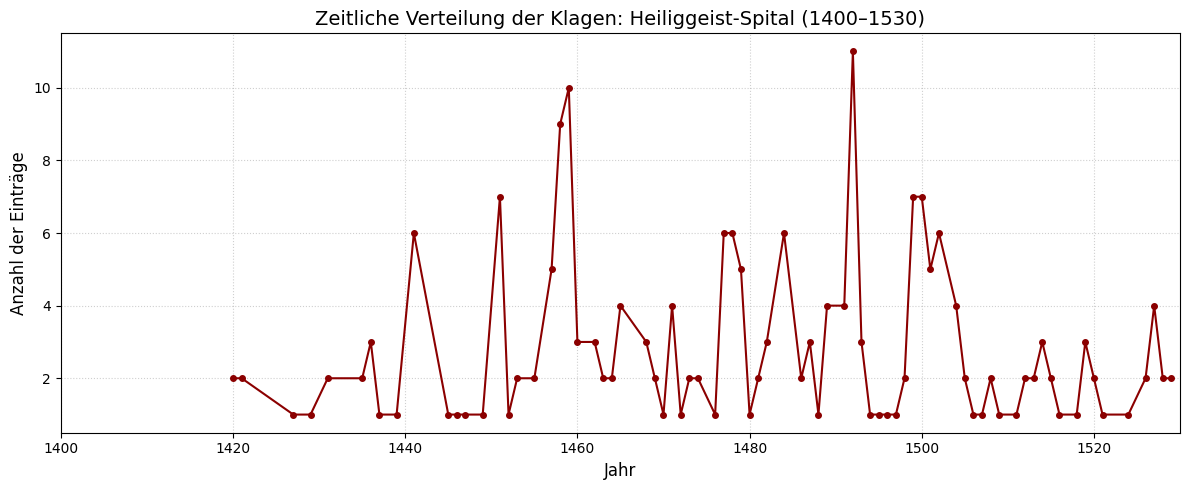

In [28]:
import matplotlib.pyplot as plt

# Hier kann die Institution ausgetauscht werden
target_institution = "Heiliggeist-Spital"
# -------------------------

# DIESER TEIL ENTSPRICHT EXAKT DEINER STATISTIK-LOGIK:
plot_data = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df["claimantOrg"] == target_institution) & 
    (froenfuerzins_korrektur_df['year'] >= 1400) & 
    (froenfuerzins_korrektur_df['year'] <= 1530)
]['year'].value_counts().sort_index()

# Diagramm-Erstellung
plt.figure(figsize=(12, 5))
plot_data.plot(kind='line', marker='o', markersize=4, color='darkred', linewidth=1.5)

plt.title(f'Zeitliche Verteilung der Klagen: {target_institution} (1400–1530)', fontsize=14)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl der Einträge', fontsize=12)
plt.xlim(1400, 1530)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Frönungen: Erstellen von Datensets für den Datenexport

In [29]:
# Hier kann die Institution ausgetauscht werden
target_institution = "Heiliggeist-Spital"
# -------------------------

# Subset-DataFrame erstellen: alle Einträge der gewählten Institution zwischen 1400 und 1530
froenungen_spital_1400_1530 = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df["claimantOrg"] == target_institution) &
    (froenfuerzins_korrektur_df['year'] >= 1400) &
    (froenfuerzins_korrektur_df['year'] <= 1530)
]

froenungen_spital_1400_1530

,collection_id,collection_house,collection_coord_x,collection_coord_y,doc_id,pages,year,text,doc_image,per_claimants,per_claimants_at_org,claimantOrg,lat,lon
1,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,6e013765-b1a3-471c-a350-1eeb9f1f1fd5_20240705,15,1458,Da hatt Johannes Schönwetter nore offie sin de...,https://files.transkribus.eu/Get?id=EKEVESLJKU...,NaN,Johannes Schönwetter,Heiliggeist-Spital,47.555152,7.589700
3,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,b16f5ad7-7007-44fb-99b9-56059e8b6f39_20240705,29,1492,Da hatt der Spittelschriber inamen des Spittel...,https://files.transkribus.eu/Get?id=DTHIZFFPKZ...,NaN,"der, der",Heiliggeist-Spital,47.555152,7.589700
4,HGB_1_024_022,Barfüsserplatz Theil von 3,2.611372e+06,1.267170e+06,b16f5ad7-7007-44fb-99b9-56059e8b6f39_20240705,29,1492,Da hatt der Spittelschriber inamen des Spittel...,https://files.transkribus.eu/Get?id=DTHIZFFPKZ...,NaN,"der, der",Heiliggeist-Spital,47.555152,7.589700
7,HGB_1_024_024,"Barfüsserplatz Theil von 5, Ecke",2.611388e+06,1.267162e+06,60bc4116-9b1c-4e24-9de1-d5dd03c7f034_20240705,19,1488,Da hatt der Spittalschriber um versessenen zin...,https://files.transkribus.eu/Get?id=EADAYHWGTS...,NaN,der,Heiliggeist-Spital,47.555080,7.589919
8,HGB_1_024_025,Barfüsserplatz Theil von 5 neben 6,2.611388e+06,1.267162e+06,8370bb80-ac76-43f4-b427-2c329fc44c06_20240705,19,1482,Da hatt der Spittalschriber zum versessenen zi...,https://files.transkribus.eu/Get?id=FKKHRTXLBI...,NaN,der,Heiliggeist-Spital,47.555080,7.589919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4287,HGB_1_218_028,Streitgasse 20,2.611399e+06,1.267179e+06,1699e19c-79fa-4043-963d-6466eff8fb46_20240705,23,1479,Da hatt der Spittalmeister Ulrich von Bruks Hü...,https://files.transkribus.eu/Get?id=HUNDGJIGZK...,NaN,der Spittalmeister,Heiliggeist-Spital,47.555224,7.590069
4322,HGB_1_227_039,"Webergasse 29, 31",2.611523e+06,1.267968e+06,75c47f57-96cc-4996-892a-98dcb0064a08_20240705,21,1492,Schultheissen-Urkunde.\nDas Spital zu Basel fr...,https://files.transkribus.eu/Get?id=NENUEZCPMU...,NaN,NaN,Heiliggeist-Spital,47.562321,7.591728
4352,HGB_1_062_015,Gemsberg Theil von 4 neben 6,2.610871e+06,1.268277e+06,de7cddeb-64ac-4896-95bc-d9a2e849c355_20240705,13,1473,Hanns von Langental Spittalmeister hatt um ver...,https://files.transkribus.eu/Get?id=QTAOJMGIWR...,NaN,Hanns von Langental Spittalmeister,Heiliggeist-Spital,47.565113,7.583077
4353,HGB_1_062_015,Gemsberg Theil von 4 neben 6,2.610871e+06,1.268277e+06,56f3fe86-734c-41c1-8d8f-702c0f8e03ad_20240705,15,1487,"Da hatt Erhart Sarwurker, Spitalmeister um ver...",https://files.transkribus.eu/Get?id=TNONIUQZGS...,NaN,"Erhart Sarwurker , Spitalmeister",Heiliggeist-Spital,47.565113,7.583077


### Code für den Export:
- Pfad anpassen!

In [30]:
import os

# 1. Pfad zum Zielordner definieren
desktop_path = os.path.expanduser("~/Desktop")

# 2. Sicherstellen, dass der Ordner existiert (erstellt ihn, falls nicht)
os.makedirs(desktop_path, exist_ok=True)

# 3. Dateiname festlegen
file_name = "froenungen_spital_1400_1530.csv"

# 4. Vollständiger Pfad zur Zieldatei
file_path = os.path.join(desktop_path, file_name)

# 5. Den DataFrame 'rente_kling_dossier_1400_1465' als CSV speichern
# index=False ist oft besser für QGIS, damit keine unnötige ID-Spalte importiert wird
froenungen_spital_1400_1530.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"Datei wurde erfolgreich gespeichert unter: {file_path}")

Datei wurde erfolgreich gespeichert unter: /Users/vonali01/Desktop/froenungen_spital_1400_1530.csv


# 3. Kartendarstellungen: Frönungen, Eigenschaft, Rente pro Institution

## Institution austauschbar - Beispiel Heiliggeist-Spital

### Frönungen
    1400 - 1530

In [31]:

# Hier Institution anpassen
target_institution = "Heiliggeist-Spital"
# -----------------------------------------------------

# 1. Daten filtern: Zeitraum UND die gewählte Organisation
# Wir filtern direkt aus dem Haupt-DataFrame
filtered_data = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df['year'] >= 1400) & 
    (froenfuerzins_korrektur_df['year'] <= 1530) &
    (froenfuerzins_korrektur_df['claimantOrg'] == target_institution)
].copy()

# Berechne die Anzahl der Treffer für die Legende
total_incidents = len(filtered_data)

# 2. Koordinaten für die Heatmap vorbereiten
locations = filtered_data[['lat', 'lon']].dropna().values.tolist()

# 3. Map definieren
m_heat = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)

# 4. Heatmap-Layer erstellen
heatmap = Heatmap(
    locations=locations,
    radius=25,
    blur=15,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.8: 'yellow', 1.0: 'red'}
)
m_heat.add(heatmap)

# 5. Blaue Kreise (Individual-Treffer) hinzufügen
for index, row in filtered_data.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        circle = Circle(
            location=(row['lat'], row['lon']),
            radius=5,           
            color='blue',       
            fill_color='blue',  
            fill_opacity=0.6,
            weight=1
        )
        m_heat.add(circle)
        
# 6. Legende mit dynamischem Counter
# Der Titel passt sich nun automatisch an die Institution und die Trefferzahl an
legend = LegendControl(
    {"Einzel-Treffer": "blue", "Dichte-Zentren": "red"}, 
    title=f"{target_institution}: {total_incidents} Treffer (1400-1530)", 
    position="bottomright"
)
m_heat.add(legend)

# Karte anzeigen
m_heat

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### Frönungen
    1400 - 1465

In [32]:

# --- ZENTRALE VARIABLE: HIER DIE INSTITUTION ÄNDERN ---
target_institution = "Heiliggeist-Spital"
# -----------------------------------------------------

# 1. Daten filtern: Zeitraum UND die gewählte Organisation
# Wir nutzen direkt das Haupt-DataFrame froenfuerzins_korrektur_df
filtered_data_early = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df['year'] >= 1400) & 
    (froenfuerzins_korrektur_df['year'] <= 1465) &
    (froenfuerzins_korrektur_df['claimantOrg'] == target_institution)
].copy()

# --- Zählung der Incidents für diesen Zeitraum ---
total_incidents = len(filtered_data_early)

# 2. Koordinaten für die Heatmap vorbereiten
locations = filtered_data_early[['lat', 'lon']].dropna().values.tolist()

# 3. Map definieren
m_heat = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)

# 4. Heatmap-Layer erstellen
heatmap = Heatmap(
    locations=locations,
    radius=25,
    blur=15,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.8: 'yellow', 1.0: 'red'}
)
m_heat.add(heatmap)

# 5. Blaue Kreise (Individual-Treffer) hinzufügen
for index, row in filtered_data_early.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        circle = Circle(
            location=(row['lat'], row['lon']),
            radius=5,           
            color='blue',       
            fill_color='blue',  
            fill_opacity=0.6,
            weight=1
        )
        m_heat.add(circle)

# --- 6. Legende mit dynamischem Titel und Counter ---
legend = LegendControl(
    {"Einzel-Treffer": "blue", "Dichte-Zentren": "yellow"}, 
    title=f"{target_institution}: {total_incidents} Treffer (1400-1465)", 
    position="bottomright"
)
m_heat.add(legend)

# Karte anzeigen
m_heat

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### Frönungen
    1466 - 1530

In [16]:


# --- ZENTRALE VARIABLE: HIER DIE INSTITUTION ÄNDERN ---
target_institution = "Heiliggeist-Spital"
# -----------------------------------------------------

# 1. Daten filtern: Zeitraum 1466 - 1530 UND die gewählte Organisation
# Wir filtern direkt aus dem Haupt-DataFrame
filtered_data_late = froenfuerzins_korrektur_df[
    (froenfuerzins_korrektur_df['year'] >= 1466) & 
    (froenfuerzins_korrektur_df['year'] <= 1530) &
    (froenfuerzins_korrektur_df['claimantOrg'] == target_institution)
].copy()

# --- Zählung der Incidents für diesen Zeitraum ---
total_incidents = len(filtered_data_late)

# 2. Koordinaten für die Heatmap vorbereiten
locations = filtered_data_late[['lat', 'lon']].dropna().values.tolist()

# 3. Map definieren
m_heat = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)

# 4. Heatmap-Layer erstellen
heatmap = Heatmap(
    locations=locations,
    radius=25,
    blur=15,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.8: 'yellow', 1.0: 'red'}
)
m_heat.add(heatmap)

# 5. Blaue Kreise (Individual-Treffer) hinzufügen
for index, row in filtered_data_late.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        circle = Circle(
            location=(row['lat'], row['lon']),
            radius=5,           
            color='blue',       
            fill_color='blue',  
            fill_opacity=0.6,
            weight=1
        )
        m_heat.add(circle)

# --- 6. Legende mit dynamischem Titel und Counter ---
legend = LegendControl(
    {"Einzel-Treffer": "blue", "Dichte-Zentren": "red"}, 
    title=f"{target_institution}: {total_incidents} Treffer (1466-1530)", 
    position="bottomright"
)
m_heat.add(legend)

# Karte anzeigen
m_heat

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### Eigenschaft (pro Dossier/Adresse)
    1466 - 1530

In [15]:


# --- ZENTRALE VARIABLE: HIER DIE INSTITUTION ÄNDERN ---
target_institution = 'Heiliggeist-Spital'
# -----------------------------------------------------

# --- 1. DATEN FILTERN (Dynamisch nach Institution und Eigenschaft) ---
filtered_eigenschaft = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) & 
    (rentsall_korrektur_df['cause'] == 'Eigenschaft') &
    (rentsall_korrektur_df['year'] >= 1400) &
    (rentsall_korrektur_df['year'] <= 1530)
].copy()

# Anzahl der einzigartigen Dossiers berechnen
total_eigenschaft_dossiers = filtered_eigenschaft['dossier'].nunique()

# --- 2. MAP INITIALISIEREN ---
m1 = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)

# --- 3. HEATMAP FÜR 'EIGENSCHAFT' ---
heat_locations = filtered_eigenschaft[['lat', 'lon']].dropna().values.tolist()

heatmap = Heatmap(
    locations=heat_locations,
    radius=30,
    blur=20,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.7: 'lime', 0.8: 'yellow', 1.0: 'red'}
)
m1.add(heatmap)

# --- 4. MARKER (PUNKTE) FÜR DIE EINZELNEN DOSSIERS ---
for index, row in filtered_eigenschaft.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        circle = Circle(
            location=(row['lat'], row['lon']),
            radius=10,
            color='orange',
            fill_color='orange',
            fill_opacity=0.9,
            weight=0
        )
        m1.add(circle)

# --- 5. LEGENDE AKTUALISIEREN (Titel und Statistik dynamisch) ---
legend_dict = {
    f"Eigenschaft ({total_eigenschaft_dossiers} Dossiers)": "orange",
    "Dichte-Zentren": "red"
}

legend = LegendControl(
    legend_dict,
    title=f"{target_institution} (1400-1530)",
    position="bottomright"
)
m1.add(legend)

# --- 6. FINALE ANZEIGE ---
m1

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### Rente (pro Dossier/Adresse)
    1466 - 1530

In [14]:


# --- ZENTRALE VARIABLE: HIER DIE INSTITUTION ÄNDERN ---
target_institution = 'Heiliggeist-Spital'
# -----------------------------------------------------

# --- 1. DATEN FILTERN (Dynamisch nach Institution und Rente) ---
filtered_Rente = rentsall_korrektur_df[
    (rentsall_korrektur_df['claimantOrg'] == target_institution) & 
    (rentsall_korrektur_df['cause'] == 'Rente') &
    (rentsall_korrektur_df['year'] >= 1400) &
    (rentsall_korrektur_df['year'] <= 1530)
].copy()

# Anzahl der einzigartigen Dossiers berechnen
total_Rente_dossiers = filtered_Rente['dossier'].nunique()

# --- 2. MAP INITIALISIEREN ---
m1 = Map(basemap=basemap, center=(47.557, 7.595), zoom=14)

# --- 3. HEATMAP FÜR 'Rente' ---
heat_locations = filtered_Rente[['lat', 'lon']].dropna().values.tolist()

heatmap = Heatmap(
    locations=heat_locations,
    radius=30,
    blur=20,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.7: 'lime', 0.8: 'yellow', 1.0: 'red'}
)
m1.add(heatmap)

# --- 4. MARKER (PUNKTE) FÜR DIE EINZELNEN DOSSIERS ---
for index, row in filtered_Rente.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        circle = Circle(
            location=(row['lat'], row['lon']),
            radius=10,
            color='orange',
            fill_color='orange',
            fill_opacity=0.9,
            weight=0
        )
        m1.add(circle)

# --- 5. LEGENDE AKTUALISIEREN (Titel und Statistik dynamisch) ---
legend_dict = {
    f"Rente ({total_Rente_dossiers} Dossiers)": "orange",
    "Dichte-Zentren": "red"
}

legend = LegendControl(
    legend_dict,
    title=f"{target_institution} (1400-1530)",
    position="bottomright"
)
m1.add(legend)

# --- 6. FINALE ANZEIGE ---
m1

Map(center=[47.557, 7.595], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…